# A/B-тест: сужение таргетинга снижает CPL

Продукт - Корпоративное страхование

Гео - регион SA/UAE. 

Проверяем гипотезу, что более узкий сегмент (C-level, мужчины 35+) имеет CR в 2 раза выше и снижает CPL по сравнению с широким таргетингом (М/Ж, 25–55).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest

## 1. Сколько трафика нужно набрать

Перед запуском теста считаем, сколько уникальных посетителей нужно привести в каждую
группу, чтобы с достоверной вероятностью поймать эффект нужного размера.

Берём базовый CR по историческим данным широкого таргетинга — 2.35% (это доля
посетителей, которые оставляют заявку). Хотим поймать удвоение
CR, с мощностью теста 80% и уровнем значимости 5%.

In [14]:
baseline_cr = 0.0235       # CR по историческим данным (широкий таргетинг)
target_cr = baseline_cr * 2  # хотим поймать удвоение CR

alpha = 0.05   # допустимая вероятность ложно найти эффект, которого нет
power = 0.80   # вероятность поймать эффект, если он реально есть

# Для долей (пропорций) размер эффекта считают не как разницу p2-p1,
# а через arcsine-преобразование (Cohen's h). Причина: дисперсия доли зависит
# от самого уровня p (p*(1-p)/n), а после преобразования arcsin(sqrt(p))
# дисперсия становится примерно постоянной — иначе расчёт n будет неточным,
# особенно когда p далеко от 0.5, как в нашем случае (CR ~2-5%).
h = 2*np.arcsin(np.sqrt(target_cr)) - 2*np.arcsin(np.sqrt(baseline_cr))

n_per_group = NormalIndPower().solve_power(
    effect_size=h, alpha=alpha, power=power, ratio=1.0, alternative='two-sided'
)
n_per_group = int(np.ceil(n_per_group))

print(f'Базовый CR: {baseline_cr:.2%}, целевой CR: {target_cr:.2%}')
print(f'Нужно набрать: {n_per_group} посетителей на группу (~{n_per_group*2} суммарно)')


Базовый CR: 2.35%, целевой CR: 4.70%
Нужно набрать: 940 посетителей на группу (~1880 суммарно)


Ориентир — около 940 посетителей на группу. Дальше смотрим, сколько собрали по факту.

## 2. Данные

Один посетитель — одна строка. `converted = 1`, если посетитель оставил заявку (стал лидом).
`id` — сквозной номер строки, реальные идентификаторы посетителей скрыты (NDA).

In [15]:
df = pd.read_csv('ab_test_data.csv')
df.head()


,id,group,converted
0,1,control,0
1,2,control,0
2,3,control,0
3,4,control,0
4,5,control,0


In [16]:
# traffic  — сколько посетителей увидело рекламу и попало в группу
# leads    — сколько из них оставили заявку
# CR       — доля лидов от трафика (leads / traffic)
stats = df.groupby('group',as_index=False)['converted'].agg(traffic='count', leads='sum', CR='mean')
stats


,group,traffic,leads,CR
0,control,1212,29,0.023927
1,test,863,39,0.045191


В тестовую группу привели 863 посетителя вместо запланированных 940. Ниже проверим, хватило ли этого, чтобы увидеть
статистически значимый эффект.

## 3. CR: тест на разницу пропорций

In [17]:
control = df[df['group'] == 'control']
test = df[df['group'] == 'test']

traffic_control, leads_control = len(control), control['converted'].sum()
traffic_test, leads_test = len(test), test['converted'].sum()

cr_control = leads_control / traffic_control
cr_test = leads_test / traffic_test

# z-тест для двух пропорций: метрика бинарная (стал лидом или нет),
z_stat, p_value = proportions_ztest(
    count=[leads_control, leads_test],
    nobs=[traffic_control, traffic_test],
    alternative='two-sided'
)

uplift = (cr_test - cr_control) / cr_control

print(f'CR control: {cr_control:.2%} ({leads_control} лидов из {traffic_control} посетителей)')
print(f'CR test:    {cr_test:.2%} ({leads_test} лидов из {traffic_test} посетителей)')
print(f'uplift: {uplift:+.1%}')
print(f'z = {z_stat:.2f}, p-value = {p_value:.4f}')


CR control: 2.39% (29 лидов из 1212 посетителей)
CR test:    4.52% (39 лидов из 863 посетителей)
uplift: +88.9%
z = -2.68, p-value = 0.0073


p-value < 0.05 — разница значима, несмотря на недобор трафика. Реальный эффект (+89%)
оказался почти таким же сильным, как ожидаемый (+100%), поэтому мощности хватило и на
чуть меньшем объёме.

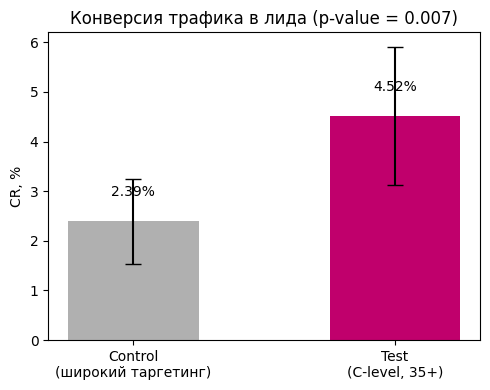

In [18]:
# 95%-й доверительный интервал для каждой доли (для графика ниже).
# Формула стандартная для пропорций: p ± 1.96 * sqrt(p*(1-p)/n)
ci_control = 1.96 * np.sqrt(cr_control*(1-cr_control)/traffic_control)
ci_test = 1.96 * np.sqrt(cr_test*(1-cr_test)/traffic_test)

fig, ax = plt.subplots(figsize=(5, 4))
groups = ['Control\n(широкий таргетинг)', 'Test\n(C-level, 35+)']
values = [cr_control*100, cr_test*100]
errors = [ci_control*100, ci_test*100]

bars = ax.bar(groups, values, yerr=errors, capsize=6, color=['#b0b0b0', '#c0006c'], width=0.5)
ax.set_ylabel('CR, %')
ax.set_title(f'Конверсия трафика в лида (p-value = {p_value:.3f})')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.savefig('cr_comparison.png', dpi=120)
plt.show()


## 4. CPL: можно ли доверять снижению

CPL = бюджет / количество лидов. Бюджет в обеих группах был установлен заранее и
откручен полностью — то есть это константа, а не случайная величина.

Раз мы уже статистически подтвердили разницу в числе лидов, из этого напрямую следует
и разница в CPL: CPL — это просто бюджет (известное число), делённый на ту же самую
величину (leads), которую мы уже проверили тестом. Никакого нового источника
случайности здесь нет, поэтому отдельный тест на CPL не нужен.

Если бы бюджет расходовался не по жёсткому лимиту, а зависел от аукциона в моменте —
CPL был бы полноценной ratio-метрикой с двумя случайными компонентами, и тогда
понадобился бы отдельный расчёт (delta method) с учётом ковариации бюджета и лидов.

In [19]:
budget_control = 3000  # бюджет группы control, $
budget_test = 2000     # бюджет группы test, $

cpl_control = budget_control / leads_control
cpl_test = budget_test / leads_test
cpl_change = (cpl_test - cpl_control) / cpl_control

print(f'CPL control: ${cpl_control:.2f}')
print(f'CPL test:    ${cpl_test:.2f}')
print(f'изменение:   {cpl_change:+.1%}')


CPL control: $103.45
CPL test:    $51.28
изменение:   -50.4%


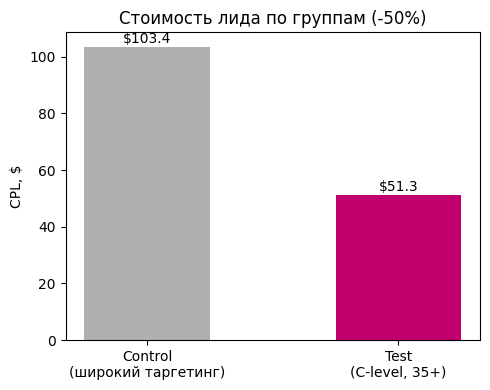

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
values = [cpl_control, cpl_test]

bars = ax.bar(groups, values, color=['#b0b0b0', '#c0006c'], width=0.5)
ax.set_ylabel('CPL, $')
ax.set_title(f'Стоимость лида по группам ({cpl_change:+.0%})')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.savefig('cpl_comparison.png', dpi=120)
plt.show()


## Итог

- CR вырос с 2.39% до 4.52% (+89%, p = 0.007) — гипотеза про C-level аудиторию подтвердилась
- CPL упал со 103 до 51 долларов (-50%) — за счёт роста конверсии, бюджет по ходу теста не менялся
- Рекомендация: переводить рекламную кампанию на узкий таргетинг, дальше следить за CPC, CPL —
  аудитория C-level со временем стоимость привлечение и лиды могут дорожать